# **Urban Cycling Route Planner**

Using the OpenStreetMap API, we created code that can query and store bicycle infrastructure to be able to run algorithms on the data. We set up a data structure using nodes and edges defining a directed graph structure. Then we implented Dijkstra's algorithm, A* and these same functions using NetworkX.
In this notebook you can try the path finding using an interactive map, check out benchmarking results and bottlenecks in the infrastructure using betweenness centrality.

In [ ]:
from data_handler import fill_data
from algorithms_networkx import convert_to_networkx, betweenness_centrality
from visualize import interactive_map, runtime_graph, explored_graph, draw_points
from benchmark import run_benchmark, test

With the section below, running the script with the desired area thats included in the overpass dataset, you'll see a generated map of the area.

In [ ]:
area = "Budapest" # change this to anything you like
network = fill_data(area)

if network == "error":
    print("Error fetching data")
else:
    graph = convert_to_networkx(network)
    map = interactive_map(network, graph)
    display(map) 

With this section, it runs a benchmark on the given areas in increasing order by size. It compares the different pathfinding algorithms from both our code and NetworkX's built-in functions.

In [3]:
areas = [
    "IX. kerület",        # smaller district
    "XI. kerület",        # medium district
    "Budapest",           # full city
    "Amsterdam",          # larger city
]
results = run_benchmark(areas, 50)

Error fetching data
Benchmarking 4615 nodes:
Result: Dijkstra: 0.0013  A*: 0.00067  NetworkX - Dijkstra: 0.00223 NetworkX - A*: 0.00102
Benchmarking 27906 nodes:
Result: Dijkstra: 0.00885  A*: 0.00397  NetworkX - Dijkstra: 0.01821 NetworkX - A*: 0.006
Benchmarking 67178 nodes:
Result: Dijkstra: 0.03336  A*: 0.01117  NetworkX - Dijkstra: 0.08378 NetworkX - A*: 0.01588


With this section, you can create a graph of the mesured runtimes, making it visibly easy to compare them.

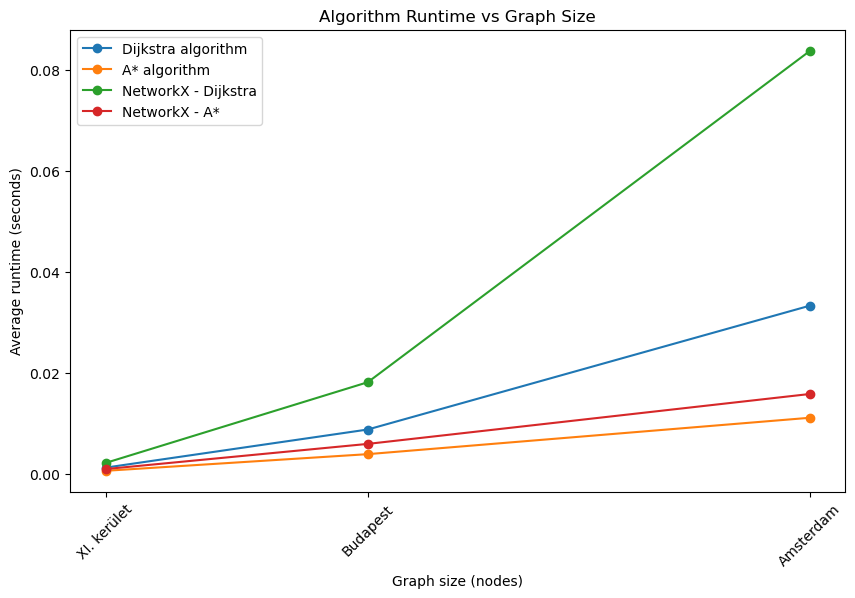

In [4]:
runtime_graph(results)

With this section, you can create a graph of the amount of cells that each pathfinding algorithm discovered, giving some information on which one is more efficient.

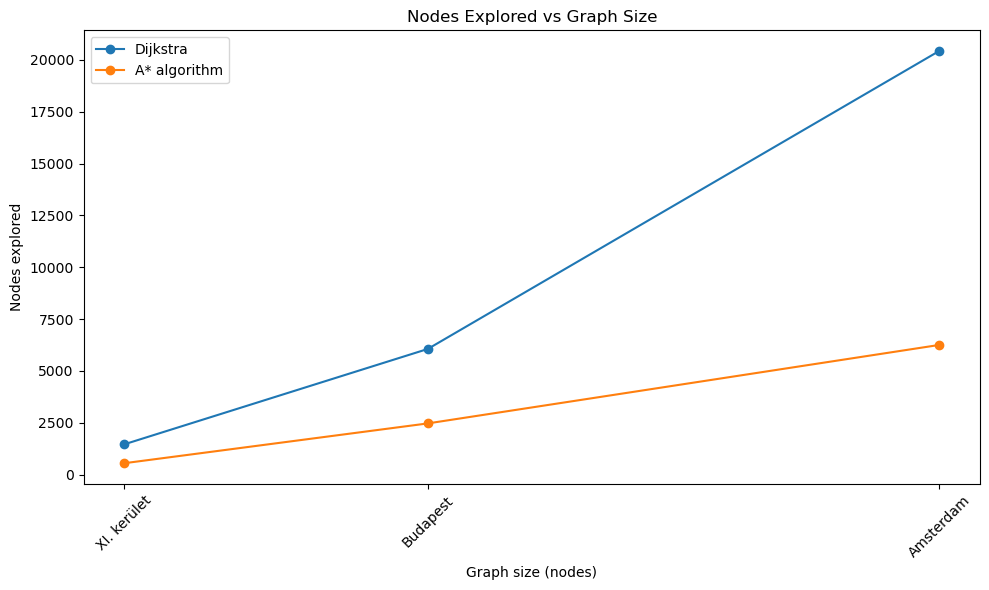

In [5]:
explored_graph(results)

With this section, you can check wheater each of the algorithms return the same path with the same amount of notes and distances.

In [6]:
test()

True
True
True
0.0
0.0
0.0


With this section, you can find the most visited Node in the dataset, finding the Node with the heaviest traffic. It runs based on a given 'n' amount of times.

In [ ]:
area = 'Budapest' #str(input('Give the name of the area you would like to search: '))
network1 = fill_data(area)
if network1 == "error":
    print("Error fetching data")
else:
    n = 10  #this is the optimal amount of times it should run
    graph = convert_to_networkx(network1)
    points = betweenness_centrality(graph, n)
    print(points)
    draw_points(network1, list(points))
